In [1]:
import atoti as tt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

username = "pvolterr"
password = "84228422"
port = 3306
database = "aida"

engine = create_engine('mysql+mysqldb://%s:%s@localhost:%i/%s'
                       %(username, password, port, database))

Welcome to atoti 0.6.4!

By using this community edition, you agree with the license available at https://docs.atoti.io/latest/eula.html.
Browse the official documentation at https://docs.atoti.io.
Join the community at https://www.atoti.io/register.

atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, set the ATOTI_DISABLE_TELEMETRY environment variable to True.

You can hide this message by setting the ATOTI_HIDE_EULA_MESSAGE environment variable to True.


In [2]:
session = tt.create_session(config={"user_content_storage": "./content", "port": 55707})
# session= tt.create_session()

In [3]:
sql = "SELECT * FROM fdg_abs;"
df = pd.read_sql_query(sql, engine)
df["delibera"] = pd.to_datetime(df["delibera"])
#df.index.set_names("regione", inplace=True)

In [4]:
sql = "SELECT * FROM io_regioni;"
regioni = pd.read_sql_query(sql, engine)
#regioni.index.set_names("FdG", inplace=True)

In [5]:
data= session.read_pandas(df,table_name="FdG", keys=['delibera'])

In [6]:
location =session.read_pandas(regioni,table_name="regioni", keys=['FdG','area'])

In [7]:
data.join(location, mapping={"regione": "FdG"})

In [8]:
cube= session.create_cube(data,"FdG")

In [19]:
cube.create_date_hierarchy(
    "giorno",
    column=data["delibera"],
    levels={"Year": "yyyy", "Quarter": "QQQ", "Month": "MM"},
)



AtotiJavaException: There is already a trigger with requested name Set date fields for store FdG for hierarchy giorno in the trigger list of store FdG.

In [10]:
h, l, m = cube.hierarchies, cube.levels, cube.measures

In [11]:
m["TOT finanziamenti"] = tt.agg.sum(data["finanziamento"])

In [12]:
cube

Cube(_name='FdG', _hierarchies=Hierarchies(), _measures=Measures())

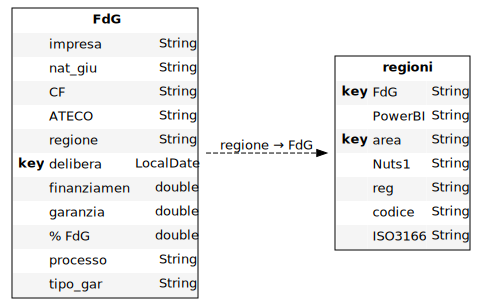

In [13]:
cube.schema

In [14]:
session.port

55707

In [15]:
session.link()

Open the notebook in JupyterLab with the atoti extension enabled to see this link.

In [16]:
h

Hierarchies()

In [17]:
m

Measures()

In [18]:
session.visualize("Prova1")

Open the notebook in JupyterLab with the atoti extension enabled to build this widget.